In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, csv, json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

import numpy.ma as ma
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import xarray as xr
import json
import ast
import sys

In [2]:
input_npz = "eval_inputs_real.npz"
retrieval_npz = "optimized_real_out.npz"

In [3]:
# ---------------------------------------------------------------------
# Load files
# ---------------------------------------------------------------------
inp = np.load(input_npz)
out = np.load(retrieval_npz)

print("Input file variables:")
print(inp.files)

print("\nRetrieval output variables:")
print(out.files)

Input file variables:
['Eval_input', 'Eval_output', 'shape', 'valid', 'lat', 'lon', 'SZA', 'VZA', 'SAA', 'VAA', 'RAA_lib']

Retrieval output variables:
['idx', 'state', 'converged', 'cost', 'post_stds', 'dofs', 'sic', 'pred_R', 'valid', 'input_valid', 'elapsed', 'n', 'shape', 'lat', 'lon', 'SZA', 'VZA', 'SAA', 'VAA', 'RAA_lib']


In [4]:
# ---------------------------------------------------------------------
# Get original 2D shape
# ---------------------------------------------------------------------
if "shape" in inp.files:
    ny, nx = inp["shape"]
elif "shape" in out.files:
    ny, nx = out["shape"]
else:
    raise ValueError("No 'shape' variable found in either input or output npz file.")

ny = int(ny)
nx = int(nx)
n_total = ny * nx

print(f"\nScene shape: {ny} x {nx} = {n_total} pixels")


Scene shape: 216 x 189 = 40824 pixels


In [5]:
# ---------------------------------------------------------------------
# Read input reflectance and retrieval output
# ---------------------------------------------------------------------
Eval_output = inp["Eval_output"]       # (N, 6), observed reflectance
state = out["state"]                   # (N, 3), CER, COT, AOD
post_stds = out["post_stds"]           # (N, 3)
dofs = out["dofs"]                     # (N, 4)
sic = out["sic"]                       # (N, 4)
pred_R = out["pred_R"]                 # (N, 6)
converged = out["converged"]           # (N,)

# Optional masks
valid = out["valid"] if "valid" in out.files else np.isfinite(state).all(axis=1)
input_valid = out["input_valid"] if "input_valid" in out.files else valid

In [6]:
# ---------------------------------------------------------------------
# Safety checks
# ---------------------------------------------------------------------
expected_shapes = {
    "Eval_output": (n_total, 6),
    "state": (n_total, 3),
    "post_stds": (n_total, 3),
    "dofs": (n_total, 4),
    "sic": (n_total, 4),
    "pred_R": (n_total, 6),
    "converged": (n_total,),
}

actual_arrays = {
    "Eval_output": Eval_output,
    "state": state,
    "post_stds": post_stds,
    "dofs": dofs,
    "sic": sic,
    "pred_R": pred_R,
    "converged": converged,
}

for name, expected_shape in expected_shapes.items():
    actual_shape = actual_arrays[name].shape
    print(f"{name}: {actual_shape}")
    if actual_shape != expected_shape:
        raise ValueError(
            f"{name} has shape {actual_shape}, but expected {expected_shape}. "
            "This usually means the retrieval output was not generated for all pixels."
        )

Eval_output: (40824, 6)
state: (40824, 3)
post_stds: (40824, 3)
dofs: (40824, 4)
sic: (40824, 4)
pred_R: (40824, 6)
converged: (40824,)


In [7]:
# ---------------------------------------------------------------------
# Reshape retrieval products to 2D maps
# ---------------------------------------------------------------------
sample_arr = np.arange(n_total, dtype=np.float32).reshape(ny, nx)

CER_retr_arr = state[:, 0].reshape(ny, nx).astype(np.float32)
COT_retr_arr = state[:, 1].reshape(ny, nx).astype(np.float32)
AOD_retr_arr = state[:, 2].reshape(ny, nx).astype(np.float32)

PostStd_CER_arr = post_stds[:, 0].reshape(ny, nx).astype(np.float32)
PostStd_COT_arr = post_stds[:, 1].reshape(ny, nx).astype(np.float32)
PostStd_AOD_arr = post_stds[:, 2].reshape(ny, nx).astype(np.float32)

DOFS_CER_arr = dofs[:, 0].reshape(ny, nx).astype(np.float32)
DOFS_COT_arr = dofs[:, 1].reshape(ny, nx).astype(np.float32)
DOFS_AOD_arr = dofs[:, 2].reshape(ny, nx).astype(np.float32)
DOFS_total_arr = dofs[:, 3].reshape(ny, nx).astype(np.float32)

SIC_CER_bits_arr = sic[:, 0].reshape(ny, nx).astype(np.float32)
SIC_COT_bits_arr = sic[:, 1].reshape(ny, nx).astype(np.float32)
SIC_AOD_bits_arr = sic[:, 2].reshape(ny, nx).astype(np.float32)
SIC_total_bits_arr = sic[:, 3].reshape(ny, nx).astype(np.float32)

Observed_R_arr = Eval_output.reshape(ny, nx, 6).astype(np.float32)
Predicted_R_arr = pred_R.reshape(ny, nx, 6).astype(np.float32)

converged_arr = converged.reshape(ny, nx).astype(bool)
valid_arr = valid.reshape(ny, nx).astype(bool)
input_valid_arr = input_valid.reshape(ny, nx).astype(bool)

In [8]:
ds = xr.Dataset(
    data_vars={
        "sample":         (("y", "x"), sample_arr),

        "CER_retr":       (("y", "x"), CER_retr_arr),
        "COT_retr":       (("y", "x"), COT_retr_arr),
        "AOD_retr":       (("y", "x"), AOD_retr_arr),

        "converged":      (("y", "x"), converged_arr),
        "valid":          (("y", "x"), valid_arr),
        "input_valid":    (("y", "x"), input_valid_arr),

        "PostStd_CER":    (("y", "x"), PostStd_CER_arr),
        "PostStd_COT":    (("y", "x"), PostStd_COT_arr),
        "PostStd_AOD":    (("y", "x"), PostStd_AOD_arr),

        "DOFS_CER":       (("y", "x"), DOFS_CER_arr),
        "DOFS_COT":       (("y", "x"), DOFS_COT_arr),
        "DOFS_AOD":       (("y", "x"), DOFS_AOD_arr),
        "DOFS_total":     (("y", "x"), DOFS_total_arr),

        "SIC_CER_bits":   (("y", "x"), SIC_CER_bits_arr),
        "SIC_COT_bits":   (("y", "x"), SIC_COT_bits_arr),
        "SIC_AOD_bits":   (("y", "x"), SIC_AOD_bits_arr),
        "SIC_total_bits": (("y", "x"), SIC_total_bits_arr),

        "Observed_R":     (("y", "x", "wl"), Observed_R_arr),
        "Predicted_R":    (("y", "x", "wl"), Predicted_R_arr),
    },
    coords={
        "y": np.arange(ny),
        "x": np.arange(nx),
        "wl": np.arange(6),
    }
)
ds

<xarray.Dataset> Size: 5MB
Dimensions:         (y: 216, x: 189, wl: 6)
Coordinates:
  * y               (y) int64 2kB 0 1 2 3 4 5 6 ... 209 210 211 212 213 214 215
  * x               (x) int64 2kB 0 1 2 3 4 5 6 ... 182 183 184 185 186 187 188
  * wl              (wl) int64 48B 0 1 2 3 4 5
Data variables: (12/20)
    sample          (y, x) float32 163kB 0.0 1.0 2.0 ... 4.082e+04 4.082e+04
    CER_retr        (y, x) float32 163kB 17.5 18.25 18.3 ... 13.03 12.79 12.4
    COT_retr        (y, x) float32 163kB 19.06 13.17 17.32 ... 30.78 25.28 27.95
    AOD_retr        (y, x) float32 163kB 0.5871 0.4069 0.6727 ... 1.127 1.198
    converged       (y, x) bool 41kB False True True True ... True True True
    valid           (y, x) bool 41kB True True True True ... True True True True
    ...              ...
    SIC_CER_bits    (y, x) float32 163kB 4.534 4.184 4.507 ... 4.195 4.164 4.882
    SIC_COT_bits    (y, x) float32 163kB 3.963 5.433 4.161 ... 2.071 2.923 2.08
    SIC_AOD_bits    (y, x) float32 163kB 4.384 4.282 3.211 ... 4.231 3.73 4.24
    SIC_total_bits  (y, x) float32 163kB 14.12 15.21 13.76 ... 12.1 12.72 12.83
    Observed_R      (y, x, wl) float32 980kB 0.4843 0.4844 ... 0.5718 0.2995
    Predicted_R     (y, x, wl) float32 980kB 0.4853 0.482 ... 0.5702 0.2997

In [9]:
bad = (
    (ds["CER_retr"]  > 40)    |
    (ds["CER_retr"]  < 4)    |
    (ds["COT_retr"]  > 80) |
    (ds["AOD_retr"]  > 4)     |
    (ds["COT_retr"]  < 1)     |
    (ds["DOFS_CER"]  < 0.6)   |
    (ds["DOFS_COT"]  < 0.6)   |
    (ds["DOFS_AOD"]  < 0.6)   |
    (ds["DOFS_total"] < 2)    |
    (ds["converged"] == False)
)

# keep good pixels
ds_clean = ds.where(~bad)

print(ds_clean)

<xarray.Dataset> Size: 5MB
Dimensions:         (y: 216, x: 189, wl: 6)
Coordinates:
  * y               (y) int64 2kB 0 1 2 3 4 5 6 ... 209 210 211 212 213 214 215
  * x               (x) int64 2kB 0 1 2 3 4 5 6 ... 182 183 184 185 186 187 188
  * wl              (wl) int64 48B 0 1 2 3 4 5
Data variables: (12/20)
    sample          (y, x) float32 163kB nan 1.0 2.0 ... 4.082e+04 4.082e+04
    CER_retr        (y, x) float32 163kB nan 18.25 18.3 ... 13.03 12.79 12.4
    COT_retr        (y, x) float32 163kB nan 13.17 17.32 ... 30.78 25.28 27.95
    AOD_retr        (y, x) float32 163kB nan 0.4069 0.6727 ... 1.212 1.127 1.198
    converged       (y, x) float64 327kB nan 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    valid           (y, x) float64 327kB nan 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    ...              ...
    SIC_CER_bits    (y, x) float32 163kB nan 4.184 4.507 ... 4.195 4.164 4.882
    SIC_COT_bits    (y, x) float32 163kB nan 5.433 4.161 ... 2.071 2.923 2.08
    SIC_AOD_bits    (y, x) 

In [10]:
dss = xr.open_dataset('PACE_OCI.20250822T123146.L1B.V3.nc',
    engine='netcdf4'
)

obs_data = xr.open_dataset(dss.encoding["source"], group="observation_data")
geo_data = xr.open_dataset(dss.encoding["source"], group="geolocation_data")

# Extract lat/lon
lat2d = geo_data["latitude"]
lon2d = geo_data["longitude"]

In [11]:
# 2. Define your target lat/lon box
lat_min, lat_max = -10, -8    # S is -ve
lon_min, lon_max = 9, 11    # E is +ve

# 3. Build a boolean mask of pixels inside that box
mask = (
    (lat2d >= lat_min) & (lat2d <= lat_max) &
    (lon2d >= lon_min) & (lon2d <= lon_max)
)

# 4. Find the minimal row/col extents that cover the mask
rows = np.any(mask, axis=1)
cols = np.any(mask, axis=0)

i0, i1 = np.where(rows)[0][[0, -1]]
j0, j1 = np.where(cols)[0][[0, -1]]
i1 += 1  # make Python slice end-inclusive
j1 += 1

# 5. Slice out each bands small patch
blue_sub  = obs_data['rhot_blue'].isel(blue_bands=64)[i0:i1, j0:j1]
red_sub   = obs_data['rhot_red'].isel(red_bands =33)[i0:i1, j0:j1]
green_sub = obs_data['rhot_blue'].isel(blue_bands=92)[i0:i1, j0:j1]  # correct green

In [12]:
# 6. Build an RGB array, scale & clamp to [0,1]
factor = 0.4
rgb_sub = np.stack([
    red_sub   / factor,
    green_sub / factor,
    blue_sub  / factor
], axis=-1)
np.clip(rgb_sub, 0, 1, out=rgb_sub)

array([[[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [0.92535985, 0.86433244, 0.8863613 ],
        [0.94980246, 0.8768051 , 0.8924943 ],
        [0.87066156, 0.8244958 , 0.85563076]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [0.9499279 , 0.8772443 , 0.89275897],
        [0.925447  , 0.8607653 , 0.8813978 ],
        [0.8585346 , 0.81617624, 0.8478072 ]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [0.93624204, 0.86516887, 0.88325864],
        [0.9146885 , 0.850712  , 0.8725089 ],
        [0.8634594 , 0.81675863, 0.84743524]],

       ...,

       [[0.8012149 , 0.7958409 , 0.8458031 ],
        [0.8458267 , 0.8277922 , 0.86909807],
        [0.87000287, 0

Colorbar ranges:
CER (np.float32(7.5730214), np.float32(20.10732))
COT (np.float32(4.503703), np.float32(40.102184))
AOD (np.float32(0.47881833), np.float32(1.3271308))
lon_plot shape: (216, 189)
lat_plot shape: (216, 189)
CER_map shape: (216, 189)
COT_map shape: (216, 189)
AOD_map shape: (216, 189)
rgb_sub shape: (216, 189, 3)


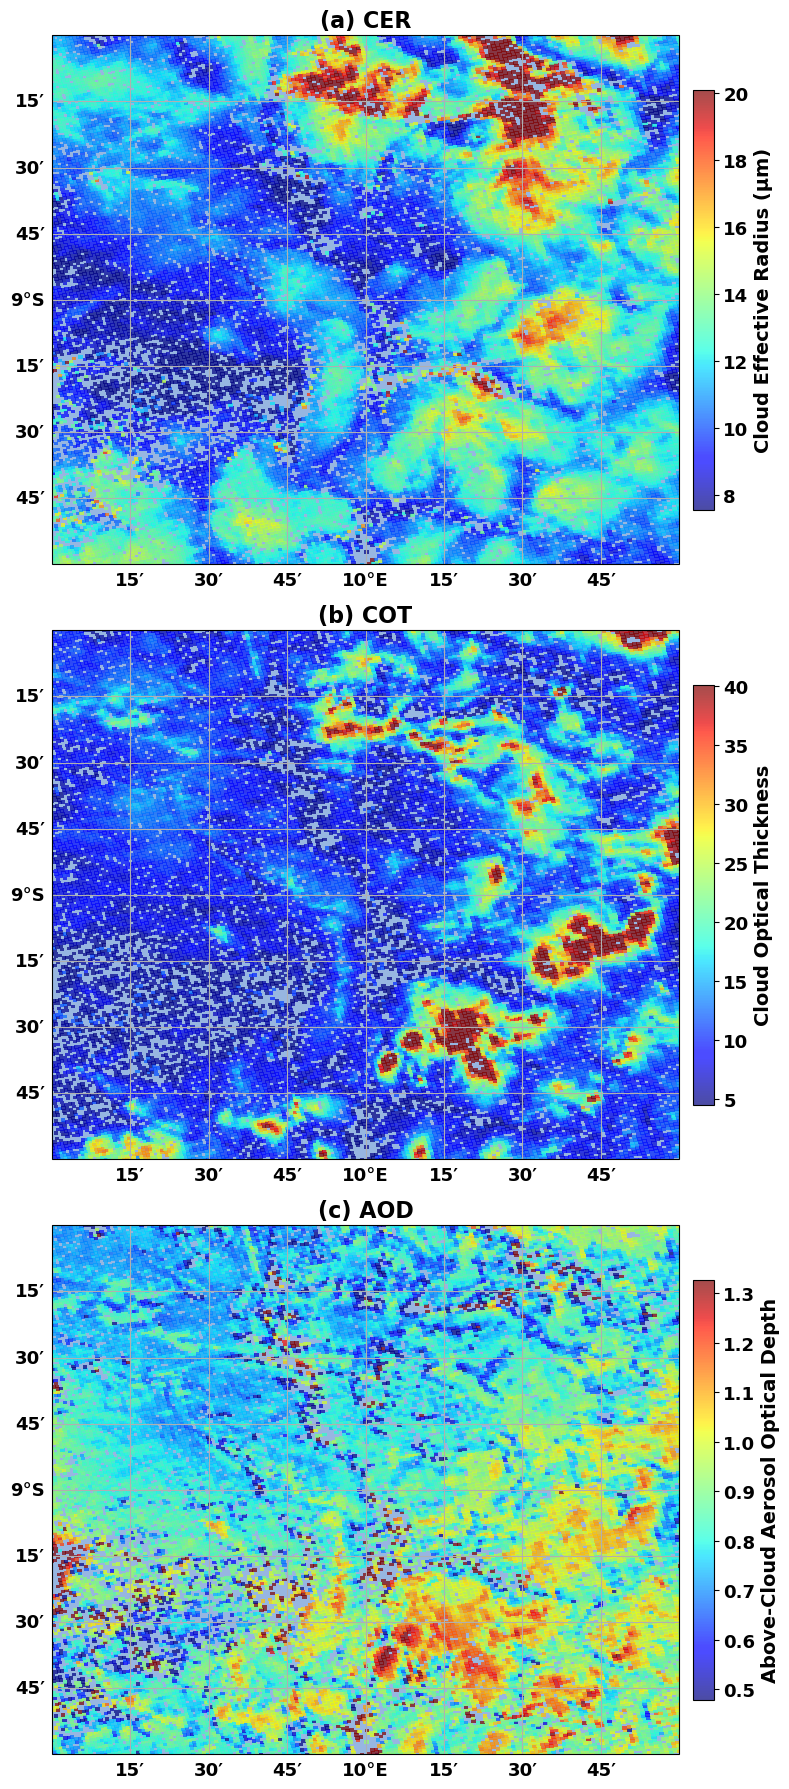

In [13]:
# --------------------------------------------
# Read retrieval maps from NetCDF
# --------------------------------------------
CER_map = ds_clean["CER_retr"].values
COT_map = ds_clean["COT_retr"].values
AOD_map = ds_clean["AOD_retr"].values

# ---- Prepare masked arrays ----
masked_CER = np.ma.masked_invalid(CER_map)
masked_COT = np.ma.masked_invalid(COT_map)
masked_AOD = np.ma.masked_invalid(AOD_map)

param_maps = {
    'CER': masked_CER,
    'COT': masked_COT,
    'AOD': masked_AOD
}

cbar_labels = {
    'CER': 'Cloud Effective Radius (µm)',
    'COT': 'Cloud Optical Thickness',
    'AOD': 'Above-Cloud Aerosol Optical Depth'
}

titles = {
    'CER': '(a) CER',
    'COT': '(b) COT',
    'AOD': '(c) AOD'
}

# --------------------------------------------
# Compute dynamic colorbar ranges (1st–99th percentile)
# --------------------------------------------
cbar_ranges = {}
for param, grid in param_maps.items():
    valid = grid.compressed()
    if len(valid) > 0:
        vmin = np.percentile(valid, 2)
        vmax = np.percentile(valid, 98)
    else:
        vmin, vmax = np.nan, np.nan
    cbar_ranges[param] = (vmin, vmax)

print("Colorbar ranges:")
for param in cbar_ranges:
    print(param, cbar_ranges[param])

# --------------------------------------------
# Coordinates for retrieval grid
# IMPORTANT: use coordinates matching retrieval shape
# --------------------------------------------
lon_plot = lon2d[i0:i1, j0:j1]
lat_plot = lat2d[i0:i1, j0:j1]

print("lon_plot shape:", lon_plot.shape)
print("lat_plot shape:", lat_plot.shape)
print("CER_map shape:", CER_map.shape)
print("COT_map shape:", COT_map.shape)
print("AOD_map shape:", AOD_map.shape)
print("rgb_sub shape:", rgb_sub.shape)

# If retrieval maps and lat/lon subset shapes do not match,
# do not use the cropped RGB overlay
use_rgb = (rgb_sub.shape[:2] == CER_map.shape) and (lon_plot.shape == CER_map.shape)

# --------------------------------------------
# Colormaps
# --------------------------------------------
cmap_dict = {
    'CER': plt.cm.jet.copy(),
    'COT': plt.cm.jet.copy(),
    'AOD': plt.cm.jet.copy()
}

for cmap in cmap_dict.values():
    cmap.set_bad(alpha=0)

# --------------------------------------------
# Create vertical figure
# --------------------------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 18),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, (param, grid) in zip(axes, param_maps.items()):

    # --------------------------------------------
    # RGB background only if shape matches
    # --------------------------------------------
    if use_rgb:
        ax.imshow(
            rgb_sub,
            origin='upper',
            extent=[
                np.nanmin(lon_plot), np.nanmax(lon_plot),
                np.nanmin(lat_plot), np.nanmax(lat_plot)
            ],
            transform=ccrs.PlateCarree(),
            aspect='auto'
        )

    # --------------------------------------------
    # Retrieval overlay
    # --------------------------------------------
    cs = ax.pcolormesh(
        lon_plot,
        lat_plot,
        grid,
        cmap=cmap_dict[param],
        shading='nearest',
        vmin=cbar_ranges[param][0],
        vmax=cbar_ranges[param][1],
        alpha=0.70 if use_rgb else 1.0,
        transform=ccrs.PlateCarree()
    )

    # --------------------------------------------
    # Map formatting
    # --------------------------------------------
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=1.0)
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)

    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.xlabel_style = {'size': 13, 'weight': 'bold'}
    gl.ylabel_style = {'size': 13, 'weight': 'bold'}

    ax.set_title(titles[param], fontsize=16, fontweight='bold')

    # --------------------------------------------
    # Colorbar
    # --------------------------------------------
    cbar = fig.colorbar(cs, ax=ax, fraction=0.0317, pad=0.02)
    cbar.ax.tick_params(labelsize=13)
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    cbar.set_label(
        cbar_labels[param],
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig("PACE_Subset_CER_COT_AOD_retrieval_1.png", dpi=500, bbox_inches="tight")
plt.show()

Colorbar ranges:
CER (np.float32(0.70046055), np.float32(2.2543952))
COT (np.float32(0.4104514), np.float32(13.043002))
AOD (np.float32(0.1097789), np.float32(0.9265375))
lon_plot shape: (216, 189)
lat_plot shape: (216, 189)
CER_map shape: (216, 189)
COT_map shape: (216, 189)
AOD_map shape: (216, 189)
rgb_sub shape: (216, 189, 3)


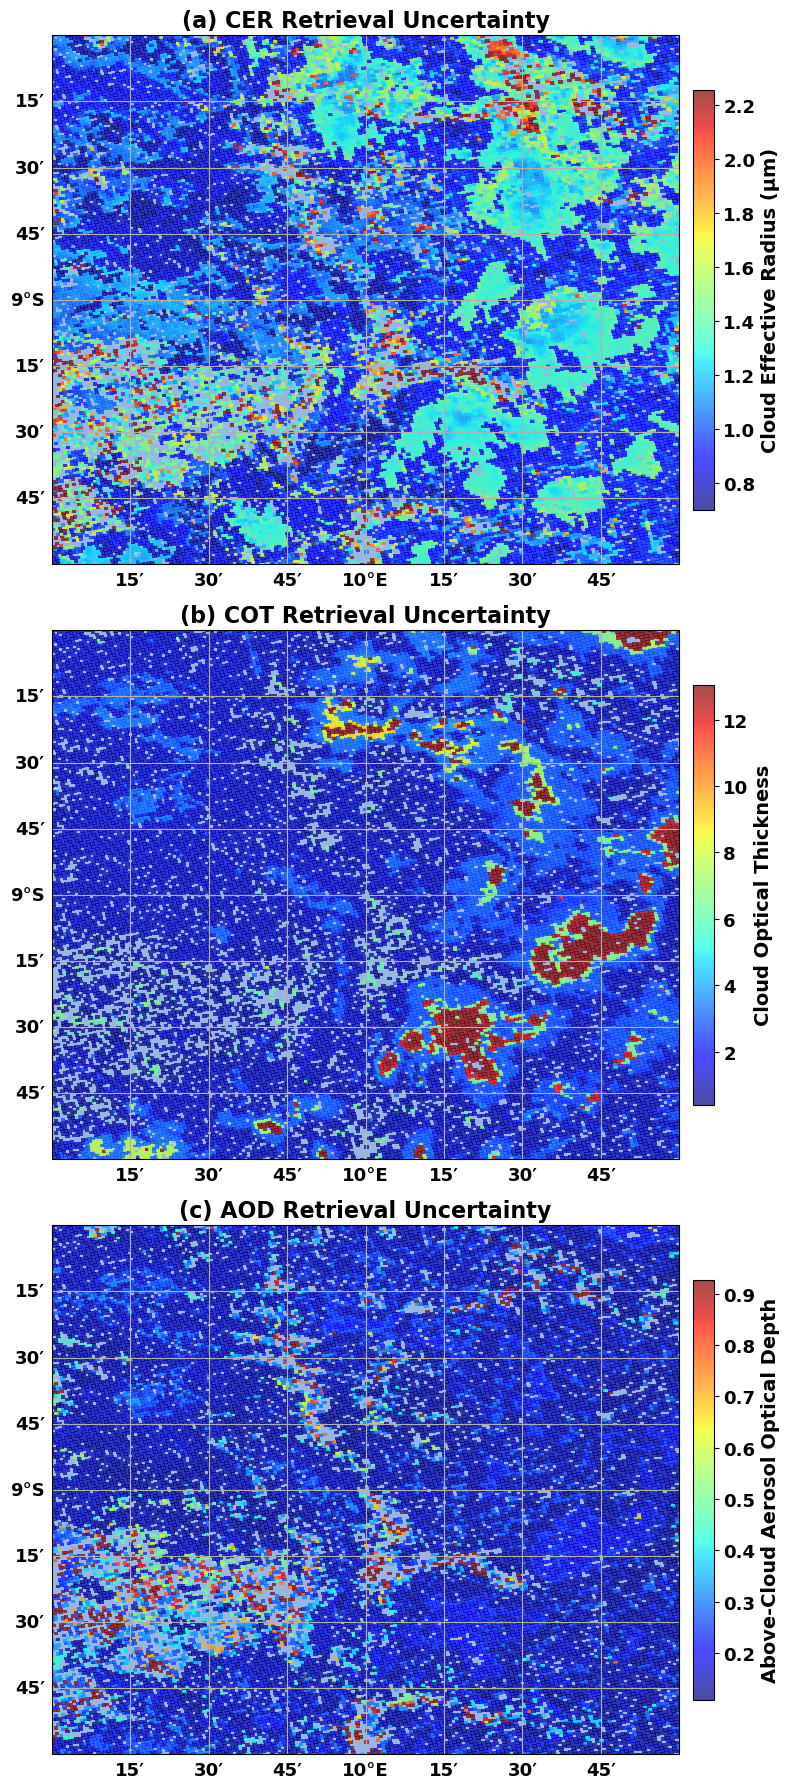

In [15]:
# --------------------------------------------
# Read retrieval maps from NetCDF
# --------------------------------------------
CER_map = ds_clean["PostStd_CER"].values
COT_map = ds_clean["PostStd_COT"].values
AOD_map = ds_clean["PostStd_AOD"].values

# ---- Prepare masked arrays ----
masked_CER = np.ma.masked_invalid(CER_map)
masked_COT = np.ma.masked_invalid(COT_map)
masked_AOD = np.ma.masked_invalid(AOD_map)

param_maps = {
    'CER': masked_CER,
    'COT': masked_COT,
    'AOD': masked_AOD
}

cbar_labels = {
    'CER': 'Cloud Effective Radius (µm)',
    'COT': 'Cloud Optical Thickness',
    'AOD': 'Above-Cloud Aerosol Optical Depth'
}

titles = {
    'CER': '(a) CER Retrieval Uncertainty',
    'COT': '(b) COT Retrieval Uncertainty',
    'AOD': '(c) AOD Retrieval Uncertainty'
}

# --------------------------------------------
# Compute dynamic colorbar ranges (1st–99th percentile)
# --------------------------------------------
cbar_ranges = {}
for param, grid in param_maps.items():
    valid = grid.compressed()
    if len(valid) > 0:
        vmin = np.percentile(valid, 2)
        vmax = np.percentile(valid, 98)
    else:
        vmin, vmax = np.nan, np.nan
    cbar_ranges[param] = (vmin, vmax)

print("Colorbar ranges:")
for param in cbar_ranges:
    print(param, cbar_ranges[param])

# --------------------------------------------
# Coordinates for retrieval grid
# IMPORTANT: use coordinates matching retrieval shape
# --------------------------------------------
lon_plot = lon2d[i0:i1, j0:j1]
lat_plot = lat2d[i0:i1, j0:j1]

print("lon_plot shape:", lon_plot.shape)
print("lat_plot shape:", lat_plot.shape)
print("CER_map shape:", CER_map.shape)
print("COT_map shape:", COT_map.shape)
print("AOD_map shape:", AOD_map.shape)
print("rgb_sub shape:", rgb_sub.shape)

# If retrieval maps and lat/lon subset shapes do not match,
# do not use the cropped RGB overlay
use_rgb = (rgb_sub.shape[:2] == CER_map.shape) and (lon_plot.shape == CER_map.shape)

# --------------------------------------------
# Colormaps
# --------------------------------------------
cmap_dict = {
    'CER': plt.cm.jet.copy(),
    'COT': plt.cm.jet.copy(),
    'AOD': plt.cm.jet.copy()
}

for cmap in cmap_dict.values():
    cmap.set_bad(alpha=0)

# --------------------------------------------
# Create vertical figure
# --------------------------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 18),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, (param, grid) in zip(axes, param_maps.items()):

    # --------------------------------------------
    # RGB background only if shape matches
    # --------------------------------------------
    if use_rgb:
        ax.imshow(
            rgb_sub,
            origin='upper',
            extent=[
                np.nanmin(lon_plot), np.nanmax(lon_plot),
                np.nanmin(lat_plot), np.nanmax(lat_plot)
            ],
            transform=ccrs.PlateCarree(),
            aspect='auto'
        )

    # --------------------------------------------
    # Retrieval overlay
    # --------------------------------------------
    cs = ax.pcolormesh(
        lon_plot,
        lat_plot,
        grid,
        cmap=cmap_dict[param],
        shading='nearest',
        vmin=cbar_ranges[param][0],
        vmax=cbar_ranges[param][1],
        alpha=0.70 if use_rgb else 1.0,
        transform=ccrs.PlateCarree()
    )

    # --------------------------------------------
    # Map formatting
    # --------------------------------------------
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=1.0)
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)

    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.xlabel_style = {'size': 13, 'weight': 'bold'}
    gl.ylabel_style = {'size': 13, 'weight': 'bold'}

    ax.set_title(titles[param], fontsize=16, fontweight='bold')

    # --------------------------------------------
    # Colorbar
    # --------------------------------------------
    cbar = fig.colorbar(cs, ax=ax, fraction=0.0317, pad=0.02)
    cbar.ax.tick_params(labelsize=13)
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    cbar.set_label(
        cbar_labels[param],
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Colorbar ranges:
CER (np.float32(0.9918683), np.float32(0.99921495))
COT (np.float32(0.93195206), np.float32(0.9999326))
AOD (np.float32(0.9046142), np.float32(0.9986609))
lon_plot shape: (216, 189)
lat_plot shape: (216, 189)
CER_map shape: (216, 189)
COT_map shape: (216, 189)
AOD_map shape: (216, 189)
rgb_sub shape: (216, 189, 3)


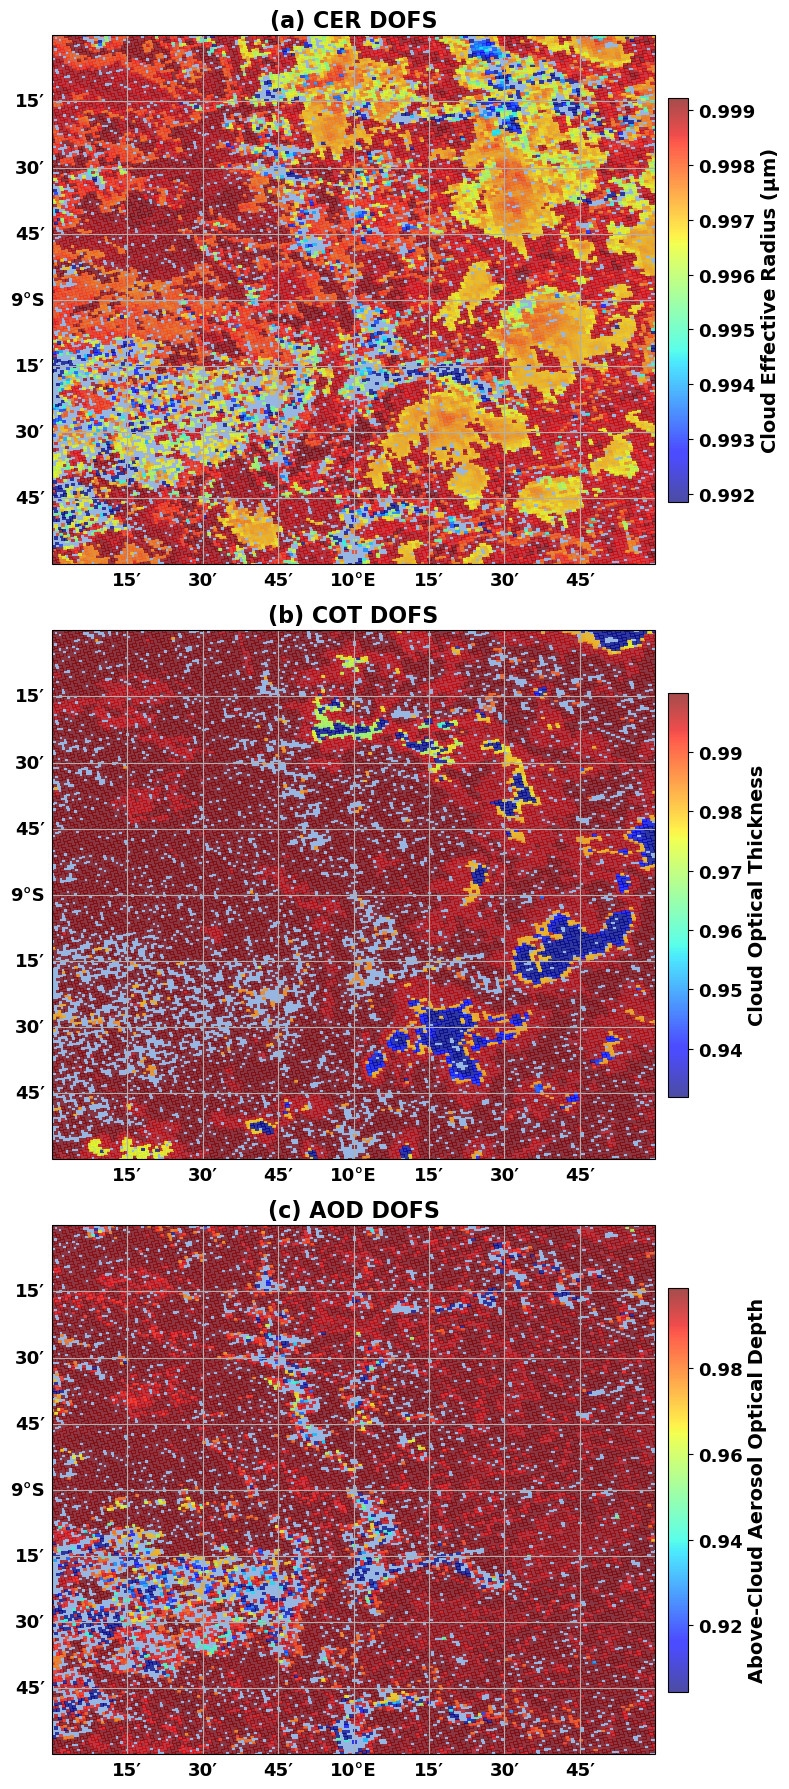

In [16]:
# --------------------------------------------
# Read retrieval maps from NetCDF
# --------------------------------------------
CER_map = ds_clean["DOFS_CER"].values
COT_map = ds_clean["DOFS_COT"].values
AOD_map = ds_clean["DOFS_AOD"].values

# ---- Prepare masked arrays ----
masked_CER = np.ma.masked_invalid(CER_map)
masked_COT = np.ma.masked_invalid(COT_map)
masked_AOD = np.ma.masked_invalid(AOD_map)

param_maps = {
    'CER': masked_CER,
    'COT': masked_COT,
    'AOD': masked_AOD
}

cbar_labels = {
    'CER': 'Cloud Effective Radius (µm)',
    'COT': 'Cloud Optical Thickness',
    'AOD': 'Above-Cloud Aerosol Optical Depth'
}

titles = {
    'CER': '(a) CER DOFS',
    'COT': '(b) COT DOFS',
    'AOD': '(c) AOD DOFS'
}

# --------------------------------------------
# Compute dynamic colorbar ranges (1st–99th percentile)
# --------------------------------------------
cbar_ranges = {}
for param, grid in param_maps.items():
    valid = grid.compressed()
    if len(valid) > 0:
        vmin = np.percentile(valid, 2)
        vmax = np.percentile(valid, 98)
    else:
        vmin, vmax = np.nan, np.nan
    cbar_ranges[param] = (vmin, vmax)

print("Colorbar ranges:")
for param in cbar_ranges:
    print(param, cbar_ranges[param])

# --------------------------------------------
# Coordinates for retrieval grid
# IMPORTANT: use coordinates matching retrieval shape
# --------------------------------------------
lon_plot = lon2d[i0:i1, j0:j1]
lat_plot = lat2d[i0:i1, j0:j1]

print("lon_plot shape:", lon_plot.shape)
print("lat_plot shape:", lat_plot.shape)
print("CER_map shape:", CER_map.shape)
print("COT_map shape:", COT_map.shape)
print("AOD_map shape:", AOD_map.shape)
print("rgb_sub shape:", rgb_sub.shape)

# If retrieval maps and lat/lon subset shapes do not match,
# do not use the cropped RGB overlay
use_rgb = (rgb_sub.shape[:2] == CER_map.shape) and (lon_plot.shape == CER_map.shape)

# --------------------------------------------
# Colormaps
# --------------------------------------------
cmap_dict = {
    'CER': plt.cm.jet.copy(),
    'COT': plt.cm.jet.copy(),
    'AOD': plt.cm.jet.copy()
}

for cmap in cmap_dict.values():
    cmap.set_bad(alpha=0)

# --------------------------------------------
# Create vertical figure
# --------------------------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 18),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, (param, grid) in zip(axes, param_maps.items()):

    # --------------------------------------------
    # RGB background only if shape matches
    # --------------------------------------------
    if use_rgb:
        ax.imshow(
            rgb_sub,
            origin='upper',
            extent=[
                np.nanmin(lon_plot), np.nanmax(lon_plot),
                np.nanmin(lat_plot), np.nanmax(lat_plot)
            ],
            transform=ccrs.PlateCarree(),
            aspect='auto'
        )

    # --------------------------------------------
    # Retrieval overlay
    # --------------------------------------------
    cs = ax.pcolormesh(
        lon_plot,
        lat_plot,
        grid,
        cmap=cmap_dict[param],
        shading='nearest',
        vmin=cbar_ranges[param][0],
        vmax=cbar_ranges[param][1],
        alpha=0.70 if use_rgb else 1.0,
        transform=ccrs.PlateCarree()
    )

    # --------------------------------------------
    # Map formatting
    # --------------------------------------------
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=1.0)
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)

    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.xlabel_style = {'size': 13, 'weight': 'bold'}
    gl.ylabel_style = {'size': 13, 'weight': 'bold'}

    ax.set_title(titles[param], fontsize=16, fontweight='bold')

    # --------------------------------------------
    # Colorbar
    # --------------------------------------------
    cbar = fig.colorbar(cs, ax=ax, fraction=0.0317, pad=0.02)
    cbar.ax.tick_params(labelsize=13)
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    cbar.set_label(
        cbar_labels[param],
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Colorbar ranges:
CER (np.float32(3.4711156), np.float32(5.1574807))
COT (np.float32(1.9386522), np.float32(6.928573))
AOD (np.float32(1.6950412), np.float32(4.7722898))
lon_plot shape: (216, 189)
lat_plot shape: (216, 189)
CER_map shape: (216, 189)
COT_map shape: (216, 189)
AOD_map shape: (216, 189)
rgb_sub shape: (216, 189, 3)


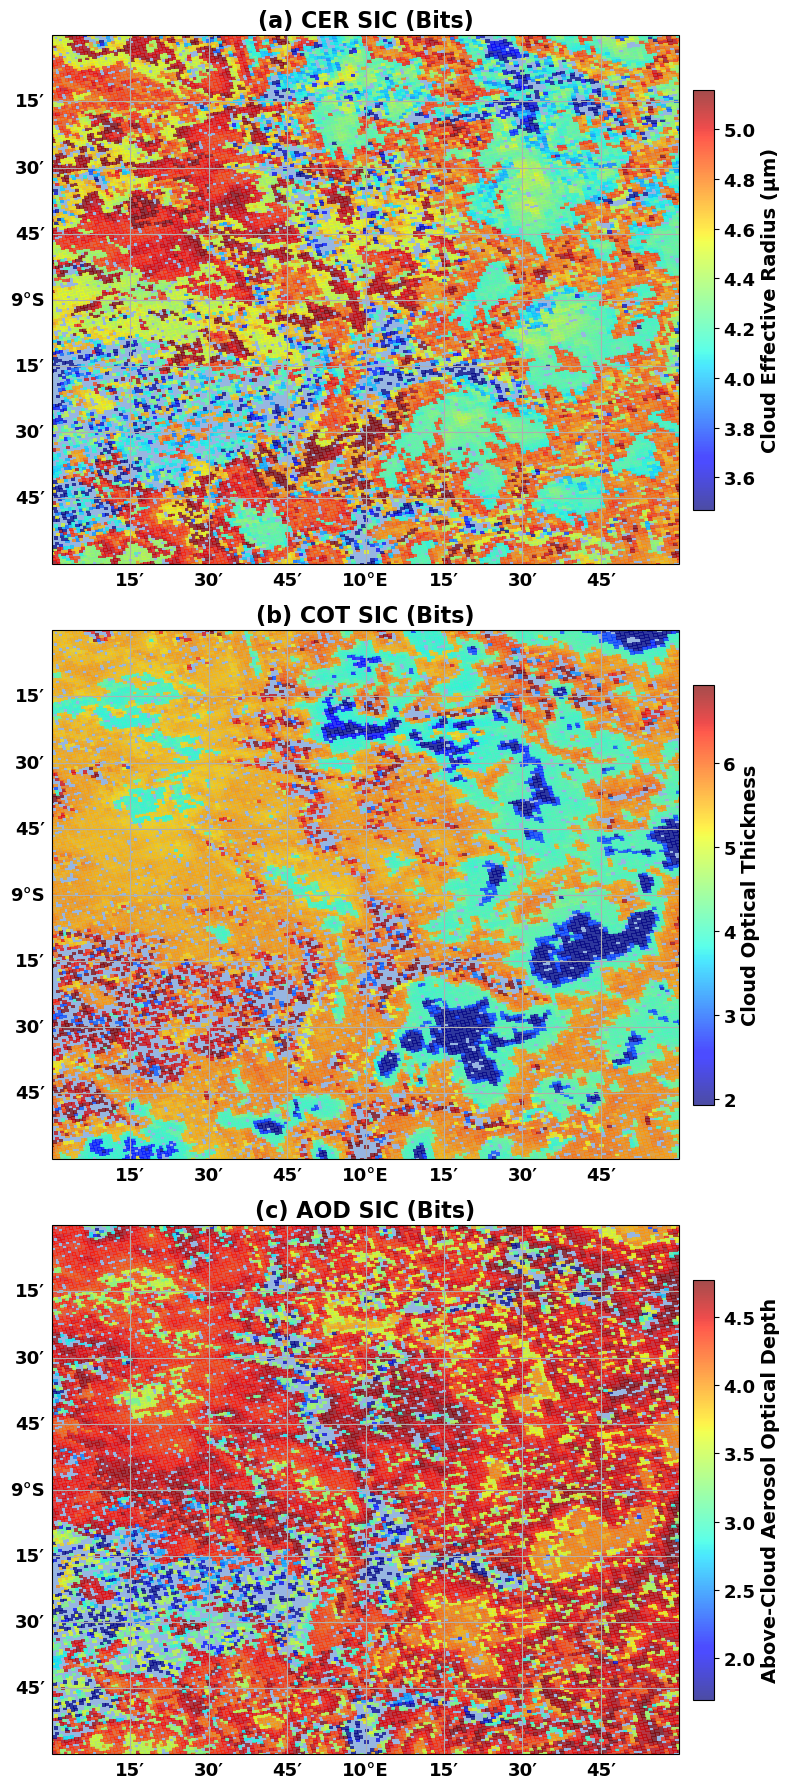

In [17]:
# --------------------------------------------
# Read retrieval maps from NetCDF
# --------------------------------------------
CER_map = ds_clean["SIC_CER_bits"].values
COT_map = ds_clean["SIC_COT_bits"].values
AOD_map = ds_clean["SIC_AOD_bits"].values

# ---- Prepare masked arrays ----
masked_CER = np.ma.masked_invalid(CER_map)
masked_COT = np.ma.masked_invalid(COT_map)
masked_AOD = np.ma.masked_invalid(AOD_map)

param_maps = {
    'CER': masked_CER,
    'COT': masked_COT,
    'AOD': masked_AOD
}

cbar_labels = {
    'CER': 'Cloud Effective Radius (µm)',
    'COT': 'Cloud Optical Thickness',
    'AOD': 'Above-Cloud Aerosol Optical Depth'
}

titles = {
    'CER': '(a) CER SIC (Bits)',
    'COT': '(b) COT SIC (Bits)',
    'AOD': '(c) AOD SIC (Bits)'
}

# --------------------------------------------
# Compute dynamic colorbar ranges (1st–99th percentile)
# --------------------------------------------
cbar_ranges = {}
for param, grid in param_maps.items():
    valid = grid.compressed()
    if len(valid) > 0:
        vmin = np.percentile(valid, 2)
        vmax = np.percentile(valid, 98)
    else:
        vmin, vmax = np.nan, np.nan
    cbar_ranges[param] = (vmin, vmax)

print("Colorbar ranges:")
for param in cbar_ranges:
    print(param, cbar_ranges[param])

# --------------------------------------------
# Coordinates for retrieval grid
# IMPORTANT: use coordinates matching retrieval shape
# --------------------------------------------
lon_plot = lon2d[i0:i1, j0:j1]
lat_plot = lat2d[i0:i1, j0:j1]

print("lon_plot shape:", lon_plot.shape)
print("lat_plot shape:", lat_plot.shape)
print("CER_map shape:", CER_map.shape)
print("COT_map shape:", COT_map.shape)
print("AOD_map shape:", AOD_map.shape)
print("rgb_sub shape:", rgb_sub.shape)

# If retrieval maps and lat/lon subset shapes do not match,
# do not use the cropped RGB overlay
use_rgb = (rgb_sub.shape[:2] == CER_map.shape) and (lon_plot.shape == CER_map.shape)

# --------------------------------------------
# Colormaps
# --------------------------------------------
cmap_dict = {
    'CER': plt.cm.jet.copy(),
    'COT': plt.cm.jet.copy(),
    'AOD': plt.cm.jet.copy()
}

for cmap in cmap_dict.values():
    cmap.set_bad(alpha=0)

# --------------------------------------------
# Create vertical figure
# --------------------------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 18),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, (param, grid) in zip(axes, param_maps.items()):

    # --------------------------------------------
    # RGB background only if shape matches
    # --------------------------------------------
    if use_rgb:
        ax.imshow(
            rgb_sub,
            origin='upper',
            extent=[
                np.nanmin(lon_plot), np.nanmax(lon_plot),
                np.nanmin(lat_plot), np.nanmax(lat_plot)
            ],
            transform=ccrs.PlateCarree(),
            aspect='auto'
        )

    # --------------------------------------------
    # Retrieval overlay
    # --------------------------------------------
    cs = ax.pcolormesh(
        lon_plot,
        lat_plot,
        grid,
        cmap=cmap_dict[param],
        shading='nearest',
        vmin=cbar_ranges[param][0],
        vmax=cbar_ranges[param][1],
        alpha=0.70 if use_rgb else 1.0,
        transform=ccrs.PlateCarree()
    )

    # --------------------------------------------
    # Map formatting
    # --------------------------------------------
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=1.0)
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)

    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.xlabel_style = {'size': 13, 'weight': 'bold'}
    gl.ylabel_style = {'size': 13, 'weight': 'bold'}

    ax.set_title(titles[param], fontsize=16, fontweight='bold')

    # --------------------------------------------
    # Colorbar
    # --------------------------------------------
    cbar = fig.colorbar(cs, ax=ax, fraction=0.0317, pad=0.02)
    cbar.ax.tick_params(labelsize=13)
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    cbar.set_label(
        cbar_labels[param],
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()